# Tokenizing Texts

In [ ]:
import os
import urllib.request
url = ("https://raw.githubusercontent.com/rasbt/"
       "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
       "the-verdict.txt")
file_path = "the-verdict.txt"
urllib.request.urlretrieve(url, file_path)

('the-verdict.txt', <http.client.HTTPMessage at 0x7f7256edc050>)

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [ ]:
len(raw_text)

20479

In [ ]:
import re
text = "Hello, world. This is a test."
result = re.split(r'(\s)',text)
print(result)

['Hello,', ' ', 'world.', ' ', 'This', ' ', 'is', ' ', 'a', ' ', 'test.']


In [ ]:
result = [item for item in result if item.strip()]
print(result)

['Hello,', 'world.', 'This', 'is', 'a', 'test.']


In [ ]:
result = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
result = [item for item in result if item.strip()]
print(result)

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in', 'the', 'height', 'of', 'his', 'glory', ',', 'he', 'had', 'dropped', 'his', 'painting', ',', 'married', 'a', 'rich', 'widow', ',', 'and', 'established', 'himself', 'in', 'a', 'villa', 'on', 'the', 'Riviera', '.', '(', 'Though', 'I', 'rather', 'thought', 'it', 'would', 'have', 'been', 'Rome', 'or', 'Florence', '.', ')', '"', 'The', 'height', 'of', 'his', 'glory', '"', '--', 'that', 'was', 'what', 'the', 'women', 'called', 'it', '.', 'I', 'can', 'hear', 'Mrs', '.', 'Gideon', 'Thwing', '--', 'his', 'last', 'Chicago', 'sitter', '--', 'deploring', 'his', 'unaccountable', 'abdication', '.', '"', 'Of', 'course', 'it', "'", 's', 'going', 'to', 'send', 'the', 'value', 'of', 'my', 'picture', "'", 'way', 'up', ';', 'but', 'I', 'don', "'", 't', 'think', 'of', 'that', ',

In [ ]:
prepros = result
print(len(prepros))

4690


In [ ]:
prepros[:10]

['I',
 'HAD',
 'always',
 'thought',
 'Jack',
 'Gisburn',
 'rather',
 'a',
 'cheap',
 'genius']

# Converting tokens into Token ID

building vocabulary

In [ ]:
all_words = sorted(set(prepros))
vocab_size = len(all_words)
print(vocab_size)

1130


In [ ]:
vocab = {token:integar for integar, token in enumerate(all_words)}

In [ ]:
print(vocab)

{'!': 0, '"': 1, "'": 2, '(': 3, ')': 4, ',': 5, '--': 6, '.': 7, ':': 8, ';': 9, '?': 10, 'A': 11, 'Ah': 12, 'Among': 13, 'And': 14, 'Are': 15, 'Arrt': 16, 'As': 17, 'At': 18, 'Be': 19, 'Begin': 20, 'Burlington': 21, 'But': 22, 'By': 23, 'Carlo': 24, 'Chicago': 25, 'Claude': 26, 'Come': 27, 'Croft': 28, 'Destroyed': 29, 'Devonshire': 30, 'Don': 31, 'Dubarry': 32, 'Emperors': 33, 'Florence': 34, 'For': 35, 'Gallery': 36, 'Gideon': 37, 'Gisburn': 38, 'Gisburns': 39, 'Grafton': 40, 'Greek': 41, 'Grindle': 42, 'Grindles': 43, 'HAD': 44, 'Had': 45, 'Hang': 46, 'Has': 47, 'He': 48, 'Her': 49, 'Hermia': 50, 'His': 51, 'How': 52, 'I': 53, 'If': 54, 'In': 55, 'It': 56, 'Jack': 57, 'Jove': 58, 'Just': 59, 'Lord': 60, 'Made': 61, 'Miss': 62, 'Money': 63, 'Monte': 64, 'Moon-dancers': 65, 'Mr': 66, 'Mrs': 67, 'My': 68, 'Never': 69, 'No': 70, 'Now': 71, 'Nutley': 72, 'Of': 73, 'Oh': 74, 'On': 75, 'Once': 76, 'Only': 77, 'Or': 78, 'Perhaps': 79, 'Poor': 80, 'Professional': 81, 'Renaissance': 82, 'Ri

In [ ]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}
    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
    def decode(self, ids):
      text = " ".join([self.int_to_str[i] for i in ids])

      text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
      return text

In [ ]:
int_to_str = {i:s for s,i in vocab.items()}
int_to_str[57]

'Jack'

In [ ]:
tokenizer = SimpleTokenizerV1(vocab)

In [ ]:
text = """Once, when I looked up,
I seemed to see a smile behind his close grayish beard
--as if he had the secret,
and were amusing himself by holding it back from me."""

In [ ]:
ids = tokenizer.encode(text)
print(ids)

[76, 5, 1090, 53, 643, 1051, 5, 53, 863, 1016, 862, 115, 905, 212, 549, 272, 507, 202, 6, 177, 566, 533, 514, 988, 861, 5, 157, 1088, 155, 547, 241, 551, 585, 191, 477, 663, 7]


In [ ]:
tokenizer.decode(ids)

'Once, when I looked up, I seemed to see a smile behind his close grayish beard -- as if he had the secret, and were amusing himself by holding it back from me.'

Adding Special Context Tokens

In [ ]:
text = "Hello, do you like tea? is this--preferred?"
tokenizer.encode(text)

KeyError: 'Hello'

In [ ]:
all_tokens = sorted(list(set(prepros)))
all_tokens.extend(["<|endoftext|>","<|unk|>"])
vocab = {token:integer for integer, token in enumerate(all_tokens)}


In [ ]:
len(vocab.items())

1132

In [ ]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}
    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        # speical rule
        preprocessed = [item if item in self.str_to_int
                else "<|unk|>" for item in preprocessed
                        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
    def decode(self, ids):
      text = " ".join([self.int_to_str[i] for i in ids])

      text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
      return text

In [ ]:
tokenizer = SimpleTokenizerV2(vocab)

In [ ]:
tokenizer.encode(text)

[1131, 5, 355, 1126, 628, 975, 10, 584, 999, 6, 1131, 10]

In [ ]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you like tea? is this -- <|unk|>?'

# Byte Pair encoding

word (including unknown words) to subtokens

In [ ]:
import tiktoken
tiktoken.__version__

'0.13.0'

In [ ]:
tokenizer= tiktoken.get_encoding("gpt2")

In [ ]:
tokenizer.encode("Hello World")

[15496, 2159]

In [ ]:
tokenizer.decode(tokenizer.encode("Hello World"))

'Hello World'

In [ ]:
text=("Hello do you like tea? <|endoftext|>, dasdasdasdas afeweehgerv in this Sunlit morning <|unk|>?")

In [ ]:
tokenizer.encode(text,allowed_special={"<|endoftext|>"})

[15496,
 466,
 345,
 588,
 8887,
 30,
 220,
 50256,
 11,
 288,
 292,
 67,
 292,
 67,
 292,
 67,
 292,
 6580,
 413,
 1453,
 71,
 70,
 712,
 287,
 428,
 3825,
 18250,
 3329,
 1279,
 91,
 2954,
 91,
 29,
 30]

# Data Sampling with Sliding window

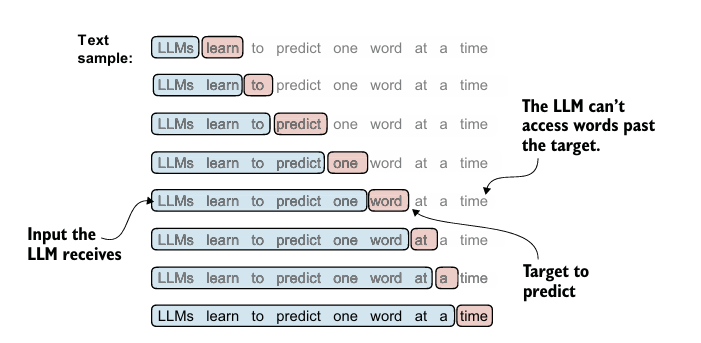


In [ ]:
import torch

In [ ]:
torch.__version__

'2.11.0+cpu'

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [ ]:
enc_sample = enc_text[50:]
context_size = 4

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:       {y}")


x: [290, 4920, 2241, 287]
y:       [4920, 2241, 287, 257]


In [ ]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(tokenizer.decode(context),"---->",tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


In [ ]:
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    def __len__(self):
          return len(self.input_ids)
    def __getitem__(self, idx):
          return self.input_ids[idx], self.target_ids[idx]

ex1
ex2

ex3
ex4

ex5 so we use drop last= true bc it has no remainder

In [ ]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                 stride=128, shuffle=True, drop_last=True,
                 num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)


    dataloader = DataLoader(
                  dataset,
                  batch_size=batch_size,
                  shuffle=shuffle,
                  drop_last=drop_last,
                  num_workers=num_workers
    )

    return dataloader

In [ ]:
with open("the-verdict.txt","r",encoding="utf-8") as f:
  raw_text=f.read()

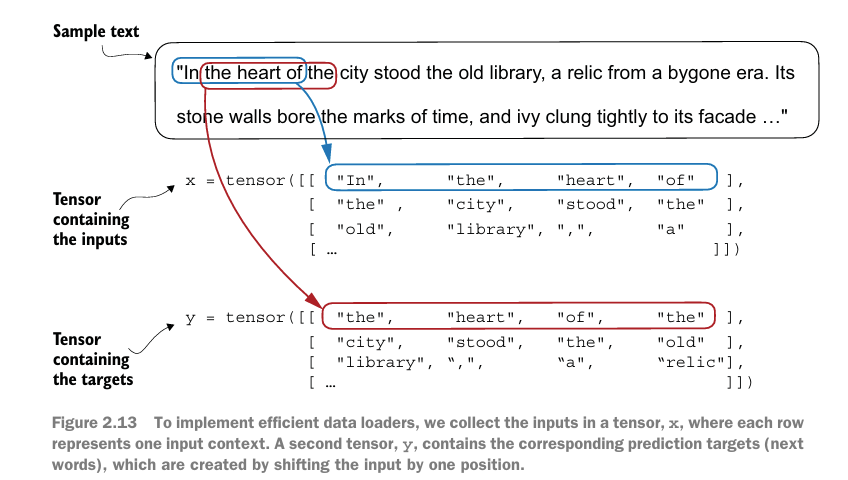

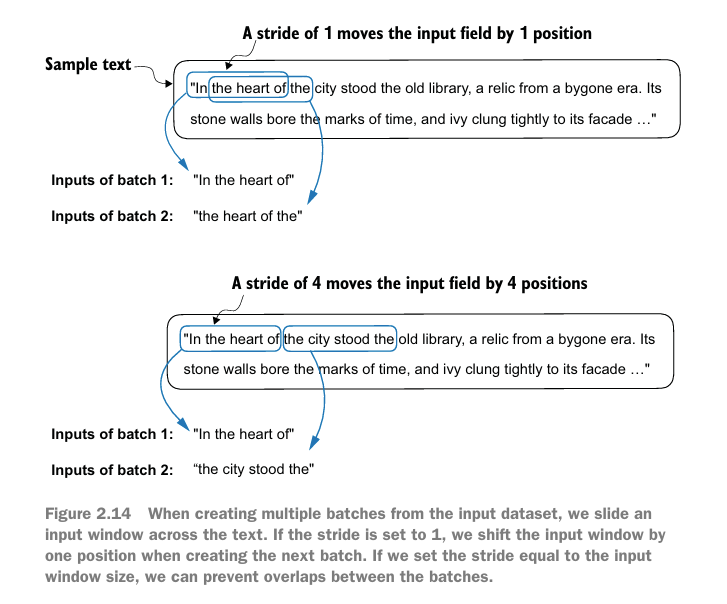

In [ ]:
dataloader = create_dataloader_v1(raw_text,
                  batch_size=1,
                  max_length=4,
                  stride=4, #slide size
                  shuffle=False)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [ ]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[1807, 3619,  402,  271]]), tensor([[ 3619,   402,   271, 10899]])]


In [ ]:
dataloader = create_dataloader_v1(raw_text,
                  batch_size=8,
                  max_length=4,
                  stride=4, #slide size
                  shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


# Creating Token Embeddings

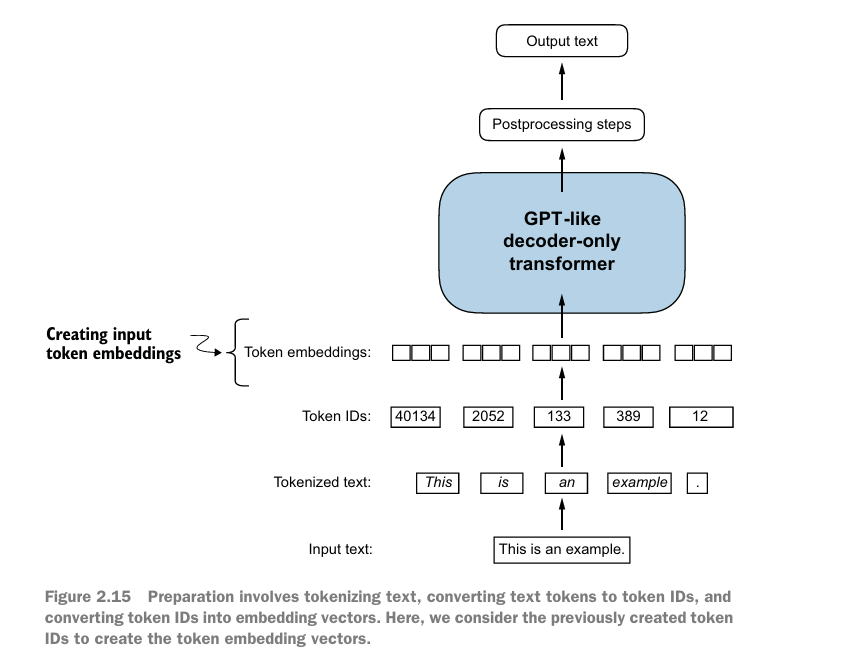

In [ ]:
input_ids = torch.tensor([2,3,5,1])

In [ ]:
vocab_size=6
output_dim=3

torch.manual_seed(123)

embedding_layer = torch.nn.Embedding(vocab_size,output_dim)

In [ ]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [ ]:
embedding_layer(torch.tensor([3]))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)

we train these values

In [ ]:
vocab_size= 50257
output_dim= 256

token_embedding_layer=torch.nn.Embedding(vocab_size, output_dim)

In [ ]:
max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8,max_length=max_length,
    stride=max_length,shuffle=False
)

data_iter=iter(dataloader)
inputs,targets = next(data_iter)

In [ ]:
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [ ]:
token_embeddings = token_embedding_layer(inputs)
token_embeddings.shape

torch.Size([8, 4, 256])

In [ ]:
token_embeddings[0,0]

tensor([ 4.9130e-01,  1.1239e+00,  1.4588e+00, -3.6530e-01, -4.0372e-02,
         1.9042e-01,  6.8024e-01, -8.6577e-01,  2.7644e-01,  6.3706e-01,
        -1.5947e+00, -2.6210e-02, -1.4804e+00, -1.0301e+00, -1.2018e+00,
         1.2016e+00,  1.8119e+00,  1.9705e+00,  1.6373e-01, -5.1866e-01,
         5.2069e-01, -1.0986e+00,  4.8871e-01,  4.3105e-01,  1.2858e+00,
        -1.9670e+00,  9.2041e-02,  4.5699e-01, -1.4753e+00, -4.4934e-01,
        -8.3517e-01, -1.1789e+00, -6.0601e-01, -5.3533e-01, -2.9543e-01,
         5.1638e-01,  4.2293e-01,  2.7947e-01, -2.4484e+00,  3.0050e-01,
         3.5847e-01,  7.4261e-01,  2.1654e-01, -9.2025e-01,  2.2604e-01,
        -8.0408e-01,  6.7722e-01,  8.9504e-01, -1.3292e+00, -1.6186e+00,
        -1.6062e+00, -8.2329e-01,  1.1738e-01, -7.6778e-01,  9.9370e-01,
         5.0167e-02,  7.0607e-02, -7.8336e-01,  4.4577e-01, -3.5213e-01,
         7.3934e-01,  3.3461e-01, -5.5481e-01, -3.8830e-01,  9.9484e-01,
         5.0054e-02, -1.5199e+00,  2.6316e-01, -1.6

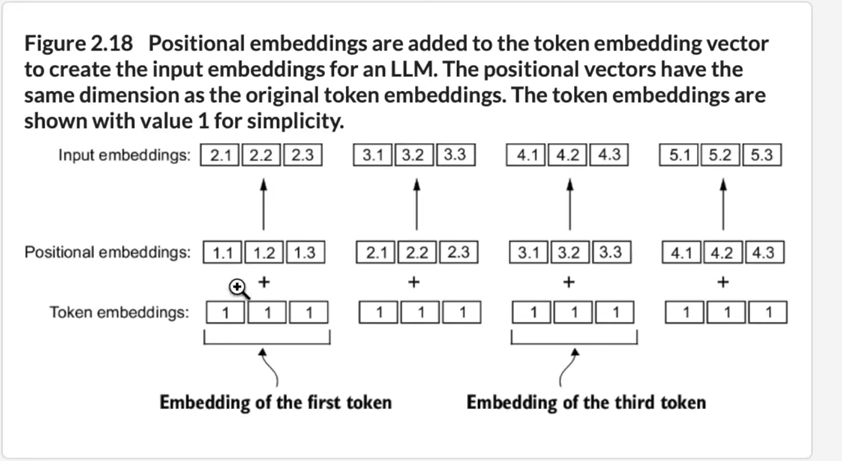

In [ ]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

In [ ]:
torch.arange(max_length)

tensor([0, 1, 2, 3])

In [ ]:
pos_embedding_layer.weight

Parameter containing:
tensor([[ 1.7375, -0.5620, -0.6303,  ..., -0.2277,  1.5748,  1.0345],
        [ 1.6423, -0.7201,  0.2062,  ...,  0.4118,  0.1498, -0.4628],
        [-0.4651, -0.7757,  0.5806,  ...,  1.4335, -0.4963,  0.8579],
        [-0.6754, -0.4628,  1.4323,  ...,  0.8139, -0.7088,  0.4827]],
       requires_grad=True)

In [ ]:
pos_embedding_layer(torch.arange(max_length))

tensor([[ 1.7375, -0.5620, -0.6303,  ..., -0.2277,  1.5748,  1.0345],
        [ 1.6423, -0.7201,  0.2062,  ...,  0.4118,  0.1498, -0.4628],
        [-0.4651, -0.7757,  0.5806,  ...,  1.4335, -0.4963,  0.8579],
        [-0.6754, -0.4628,  1.4323,  ...,  0.8139, -0.7088,  0.4827]],
       grad_fn=<EmbeddingBackward0>)

In [ ]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


In [ ]:
input_embeddings = pos_embeddings + token_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])
